In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2)

In [2]:
data = np.loadtxt("data/houses.txt", delimiter=',', skiprows=1)
X_train = data[:, :4]
y_train = data[:, 4]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (99, 4), y_train shape: (99,)


In [3]:
X_features = ['size(sqft)','bedrooms','floors','age']
w_init = np.array([0.39133535, 18.75376741, -53.36032453, -26.42131618])
b_init = 785.1811367994083

print(f"Shape of w_init: {w_init.shape} w_init: {w_init}")
print(f"b_init: {b_init}")
print(f"X_features: {X_features}")

Shape of w_init: (4,) w_init: [  0.39  18.75 -53.36 -26.42]
b_init: 785.1811367994083
X_features: ['size(sqft)', 'bedrooms', 'floors', 'age']


In [4]:
def predict(X, w, b):
    p = np.dot(w, X) + b
    return p

In [5]:
#Predict for a single row

x_init = X_train[0]
print(f"Shape of x_init: {x_init.shape}, x_init: {x_init}")

firs = predict(x_init, w_init, b_init)
print(f"first_pred: {firs:.4f}")

Shape of x_init: (4,), x_init: [1.24e+03 3.00e+00 1.00e+00 6.40e+01]
first_pred: -416.0609


In [6]:
#Feature Scaling

def feature_scal(x):
    mu = np.mean(x, axis=0)
    sigma = np.std(x, axis=0)
    X_norm = (x - mu) / sigma
    return X_norm, mu, sigma

In [7]:
# Implement feature scaling on X_train

X_norm, X_mu, X_sigma = feature_scal(X_train)
print(f"Peak to peak range of X_train: {np.ptp(X_train, axis=0)}")
print(f"Peak to peak range of X_norm:  {np.ptp(X_norm, axis=0)}")

Peak to peak range of X_train: [2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to peak range of X_norm:  [5.85 6.14 2.06 3.69]


In [8]:
# Compute cost with whole training data
def compute_cost(x, y, w, b):
    m = len(x)
    total_cost = 0
    for i in range(m):
        f_cc = predict(x[i], w, b)
        total_cost += (f_cc - y[i])**2
    return total_cost / (2 * m)

In [9]:
#Find compute cost value for the training data
c_cost = compute_cost(X_norm, y_train, w_init, b_init)
print(f"prediction cost for w_init: {c_cost}")

prediction cost for w_init: 95387.90957572861


In [10]:
#Compute Gradient
def compute_gradient(x, y, w, b):
    m, n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0
    for i in range(m):
        err = np.dot(w, x[i]) + b - y[i]
        for j in range(n):
            dj_dw[j] += err * x[i, j]
        dj_db = dj_db + err
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_dw, dj_db

In [11]:
dj_dwd, dj_dbd = compute_gradient(X_norm, y_train, w_init, b_init)
print(f"dj_dw: {dj_dwd}")
print(f"dj_db: {dj_dbd}")

dj_dw: [-103.37  -29.29  -73.83   42.51]
dj_db: 422.0250559913276


In [12]:
def gradient_descent(X, y, w_init, b_init, cost_function, gradient_function, alpha, num_iterator):
    w = copy.deepcopy(w_init)
    j_history = []
    b = b_init
    for i in range(num_iterator):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        j_history.append(cost_function(X, y, w, b))
    return w, b, j_history

In [13]:
# Initialize parameters
initial_w = np.zeros(X_norm.shape[1])
initial_b = 0.0
num_iterator = 1000
alpha = 0.1

# Run gradient descent on NORMALIZED data
w_final, b_final, J_hist = gradient_descent(
    X_norm, y_train, initial_w, initial_b,
    compute_cost, compute_gradient,
    alpha, num_iterator
)

print(f"b,w found by gradient descent: {b_final:0.2f}, {w_final}")

# Show predictions for first 5 houses
for i in range(5):
    pred = np.dot(X_norm[i], w_final) + b_final
    print(f"prediction: {pred:0.2f}, target value: {y_train[i]}")

b,w found by gradient descent: 363.16, [110.56 -21.27 -32.71 -37.97]
prediction: 295.18, target value: 300.0
prediction: 485.98, target value: 509.8
prediction: 389.52, target value: 394.0
prediction: 492.15, target value: 540.0
prediction: 420.25, target value: 415.0


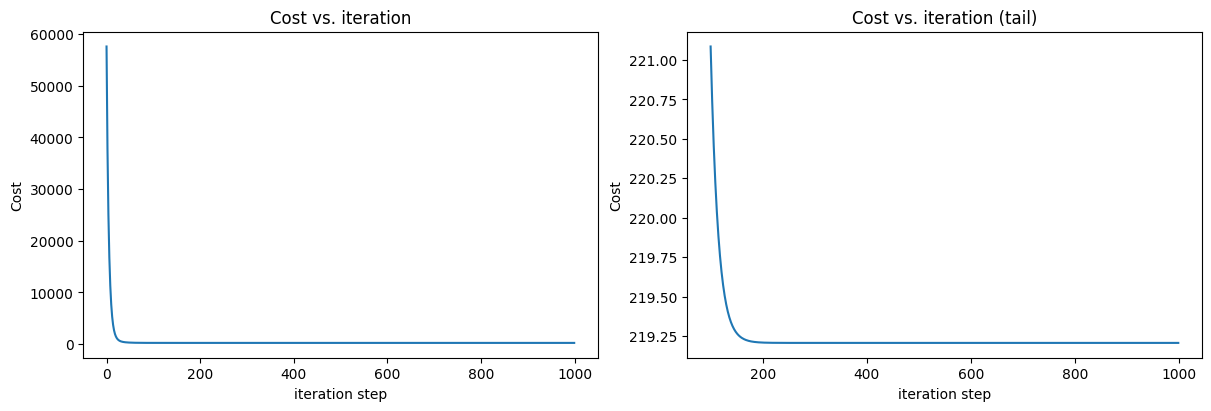

In [14]:
# Plot cost versus iteration
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration")
ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel("Cost"); ax2.set_ylabel("Cost")
ax1.set_xlabel("iteration step"); ax2.set_xlabel("iteration step")
plt.show()

In [15]:
# Predict price for a NEW house
x_house = np.array([1200, 3, 1, 40])

# Normalize using the SAME mu and sigma from training
x_house_norm = (x_house - X_mu) / X_sigma

prediction = np.dot(x_house_norm, w_final) + b_final
print(f"Predicted price of a 1200 sqft, 3 bed, 1 floor, 40 yrs old house = ${prediction*1000:0.0f}")

Predicted price of a 1200 sqft, 3 bed, 1 floor, 40 yrs old house = $318709
